# Tutorial 1b: optimizers from scratch
**Deep Learning 89-6877, Fall 2026.** TA: Tal Fiskus.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/idansc/dl-course-2026/blob/main/tutorials/T01b_optimizers.ipynb)
· Recap slides: [T01b_optimizers_recap.pdf](https://github.com/idansc/dl-course-2026/blob/main/tutorials/recap/T01b_optimizers_recap.pdf)

Plan for today (≈ 60 min):
1. Lecture recap: GD, momentum, AdaGrad/RMSProp, Adam, Newton, Muon (10 min)
2. SGD, momentum, Nesterov, AdaGrad, Adam, AdamW as `torch.optim.Optimizer` subclasses (15 min)
3. Second order: Newton vs GD and the condition number; Muon's Newton–Schulz step (10 min)
4. Learning-rate schedules: warmup-cosine and WSD (5 min)
5. All optimizers on Rosenbrock and on an MLP for FashionMNIST (10 min)
6. Why Adam needs warmup (10 min)
7. If time: L-BFGS

Runs on CPU (Colab or laptop) in a few minutes. Cells marked ✏️ are for you to try.

In [1]:
import math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device, "| torch", torch.__version__)

device: mps | torch 2.14.1


## 1. Lecture recap

**Training** = minimize the average loss over the training set, $L(w)=\frac1N\sum_i \ell(f(x_i;w),y_i) + \lambda R(w)$. The gradient comes from backprop on the computational graph (Tutorial 1). We pick hyperparameters on a validation split and report the metric (here: accuracy) on a held-out test split.

**Gradient descent** $w_{t+1} = w_t - \eta\,\nabla L(w_t)$. **SGD** estimates $\nabla L$ on a minibatch.

**Convergence on a quadratic.** For $L(w)=\tfrac12 w^\top A w - b^\top w$ with eigenvalues $\mu=\lambda_{\min}\le\dots\le\lambda_{\max}=L$, GD with $\eta = 1/L$ contracts the error by
$$\|w_t-w^*\| \le \Big(1-\tfrac{1}{\kappa}\Big)^t\|w_0-w^*\|,\qquad \kappa = L/\mu .$$
Large $\kappa$ (a long, narrow valley) = slow progress along the flat direction, jitter along the steep one. GD diverges for $\eta > 2/L$.

**Momentum** (velocity = running sum of gradients): $v_{t+1} = \rho v_t + \nabla L(w_t)$, $\;w_{t+1} = w_t - \eta v_{t+1}$, with $\rho = 0.9$ or $0.99$. With tuned $\eta,\rho$ the rate on a quadratic becomes $\frac{\sqrt\kappa-1}{\sqrt\kappa+1}\approx 1-\tfrac{2}{\sqrt\kappa}$.
**Nesterov**: take the gradient at the look-ahead point $w_t - \eta\rho v_t$.

**AdaGrad**: per-coordinate scaling by the history, $s_t = s_{t-1} + g_t^2$, $\;w \mathrel{-}= \eta\, g_t/(\sqrt{s_t}+\epsilon)$: steep directions are damped, flat ones accelerated; the step only shrinks. **RMSProp**: a leaky $s_t = \beta s_{t-1} + (1-\beta) g_t^2$.

**Adam** = momentum + RMSProp + bias correction ($\beta_1=0.9,\ \beta_2=0.999,\ \eta=10^{-3}$ is the usual start):
$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t,\quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2,\quad \hat m_t = \frac{m_t}{1-\beta_1^t},\quad \hat v_t = \frac{v_t}{1-\beta_2^t},\quad w_t = w_{t-1} - \eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}.$$
**AdamW** decouples weight decay from the adaptive scaling: $w \leftarrow (1-\eta\lambda)\,w$ before the Adam step, instead of adding $\lambda w$ to $g_t$ (which Adam would then divide by $\sqrt{\hat v_t}$).

**Newton** (second order): minimize the quadratic Taylor model, $w^* = w_0 - H^{-1}\nabla L(w_0)$. Exact in one step on a quadratic, but $H$ has $N^2$ entries and inverting it costs $O(N^3)$. Quasi-Newton (BFGS, L-BFGS) approximates $H^{-1}$ from gradient history.

**Muon** treats a weight matrix as a matrix: momentum $M_t$, then replace it by its nearest semi-orthogonal matrix $UV^\top$ (where $M=U\Sigma V^\top$), computed with a few Newton–Schulz iterations $X \leftarrow aX + b(XX^\top)X + c(XX^\top)^2X$. Every singular direction gets the same step size.

**Schedules.** Linear **warmup** then **cosine** decay to ~0; or **WSD** (warmup–stable–decay): constant LR and a short decay at the end, so one long run can be branched into several training lengths.

## 2. Optimizers as `torch.optim.Optimizer` subclasses

An optimizer holds `param_groups` (lists of tensors + hyperparameters like `lr`) and a per-parameter `state` dict for its buffers. `step()` reads `p.grad` and updates `p` in place under `torch.no_grad()`. We follow PyTorch's exact conventions so we can compare numbers:
- SGD momentum: $b \leftarrow \rho b + g$ (with $b = g$ at the first step), step along $b$. **Nesterov** in PyTorch's form steps along $g + \rho b$ (the look-ahead rewritten so the gradient is taken at the current point).
- AdaGrad: $\epsilon = 10^{-10}$ outside the square root.
- Adam: $\epsilon = 10^{-8}$ outside the square root of $\hat v$.

In [2]:
class MySGD(torch.optim.Optimizer):
    def __init__(self, params, lr, momentum=0.0, nesterov=False, weight_decay=0.0):
        super().__init__(params, dict(lr=lr, momentum=momentum, nesterov=nesterov, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr, rho, wd = group["lr"], group["momentum"], group["weight_decay"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad + wd * p                      # L2 regularization = weight decay for SGD
                if rho > 0:
                    state = self.state[p]
                    if "buf" not in state:
                        state["buf"] = g.clone()
                    else:
                        state["buf"].mul_(rho).add_(g)
                    g = g + rho * state["buf"] if group["nesterov"] else state["buf"]
                p.add_(g, alpha=-lr)


class MyAdaGrad(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-2, eps=1e-10):
        super().__init__(params, dict(lr=lr, eps=eps))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if "sum" not in state:
                    state["sum"] = torch.zeros_like(p)
                state["sum"].addcmul_(p.grad, p.grad)
                p.addcdiv_(p.grad, state["sum"].sqrt() + group["eps"], value=-group["lr"])


class MyAdam(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0,
                 decoupled=False, bias_correction=True):
        super().__init__(params, dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay,
                                      decoupled=decoupled, bias_correction=bias_correction))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr, (b1, b2), eps, wd = group["lr"], group["betas"], group["eps"], group["weight_decay"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if not state:
                    state["t"], state["m"], state["v"] = 0, torch.zeros_like(p), torch.zeros_like(p)
                g = p.grad
                if wd and not group["decoupled"]:
                    g = g + wd * p                       # Adam's L2: the decay goes through 1/sqrt(v)
                if wd and group["decoupled"]:
                    p.mul_(1 - lr * wd)
                state["t"] += 1
                t, m, v = state["t"], state["m"], state["v"]
                m.mul_(b1).add_(g, alpha=1 - b1)
                v.mul_(b2).addcmul_(g, g, value=1 - b2)
                if group["bias_correction"]:
                    m_hat, v_hat = m / (1 - b1 ** t), v / (1 - b2 ** t)
                else:
                    m_hat, v_hat = m, v
                p.addcdiv_(m_hat, v_hat.sqrt() + eps, value=-lr)


class MyAdamW(MyAdam):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-2):
        super().__init__(params, lr, betas, eps, weight_decay, decoupled=True)

**Check.** Two identical copies of some parameters, one per optimizer. At every step both receive the same gradient, $g = w + \text{noise}$ (the gradient of $\tfrac12\|w\|^2$ plus a shared noise sample), so any difference comes from the update rule. Float64, 100 steps.

In [3]:
def compare(mine_cls, ref_cls, steps=100, **kw):
    torch.manual_seed(0)
    init = [torch.randn(8, 5, dtype=torch.float64), torch.randn(5, dtype=torch.float64)]
    pa = [w.clone().requires_grad_() for w in init]
    pb = [w.clone().requires_grad_() for w in init]
    opt_a, opt_b = mine_cls(pa, **kw), ref_cls(pb, **kw)
    gen = torch.Generator().manual_seed(1)
    for _ in range(steps):
        for a, b in zip(pa, pb):
            noise = torch.randn(a.shape, generator=gen, dtype=torch.float64)
            a.grad = a.detach() + noise
            b.grad = b.detach() + noise
        opt_a.step(); opt_b.step()
    diff = max((a - b).abs().max().item() for a, b in zip(pa, pb))
    moved = max((a - w).abs().max().item() for a, w in zip(pa, init))
    print(f"{mine_cls.__name__:10s} {str(kw):55s} max |mine − torch| = {diff:.1e}   (params moved up to {moved:.2f})")

compare(MySGD, torch.optim.SGD, lr=0.05)
compare(MySGD, torch.optim.SGD, lr=0.05, weight_decay=0.1)
compare(MySGD, torch.optim.SGD, lr=0.05, momentum=0.9)
compare(MySGD, torch.optim.SGD, lr=0.05, momentum=0.9, nesterov=True)
compare(MyAdaGrad, torch.optim.Adagrad, lr=0.1)
compare(MyAdam, torch.optim.Adam, lr=0.01)
compare(MyAdam, torch.optim.Adam, lr=0.01, weight_decay=0.1)
compare(MyAdamW, torch.optim.AdamW, lr=0.01, weight_decay=0.1)

MySGD      {'lr': 0.05}                                            max |mine − torch| = 0.0e+00   (params moved up to 2.15)
MySGD      {'lr': 0.05, 'weight_decay': 0.1}                       max |mine − torch| = 2.8e-17   (params moved up to 2.13)
MySGD      {'lr': 0.05, 'momentum': 0.9}                           max |mine − torch| = 0.0e+00   (params moved up to 2.43)
MySGD      {'lr': 0.05, 'momentum': 0.9, 'nesterov': True}         max |mine − torch| = 1.4e-16   (params moved up to 2.15)
MyAdaGrad  {'lr': 0.1}                                             max |mine − torch| = 0.0e+00   (params moved up to 1.29)
MyAdam     {'lr': 0.01}                                            max |mine − torch| = 3.3e-16   (params moved up to 0.79)
MyAdam     {'lr': 0.01, 'weight_decay': 0.1}                       max |mine − torch| = 2.2e-16   (params moved up to 0.81)
MyAdamW    {'lr': 0.01, 'weight_decay': 0.1}                       max |mine − torch| = 3.3e-16   (params moved up to 0.95)


All differences are at float64 round-off while the parameters moved by $O(1)$: the update rules match PyTorch's.

✏️ `torch.optim.Adam(weight_decay=0.1)` and `torch.optim.AdamW(weight_decay=0.1)` are different algorithms. Print `max |Adam − AdamW|` after the 100 steps above. For which parameters does Adam's L2 term decay the weights less than AdamW does? (Hint: the decay is divided by $\sqrt{\hat v}$.)

**Past exam question (Moed C, 2026)**

A non-convex loss is optimized with SGD with momentum, using the update rule
$$v_{t+1} = \mu v_t - \eta \nabla L(\theta_t), \qquad \theta_{t+1} = \theta_t + v_{t+1}.$$
Which of the following statements about the role of the momentum $\mu$ are **true**? (More than one may be correct.)
1. Momentum lets the optimizer build up velocity in the direction of consistent gradients, which helps it cross flat regions (plateaus) and damps oscillations in directions where the gradient is noisy.
2. Momentum can be interpreted as an exponentially weighted moving average of the gradients accumulated so far.
3. Momentum only changes the size of the current step at each iteration, and does not use gradients from previous steps at all.
4. Momentum guarantees convergence to the global optimum, even for non-convex losses.

**1 and 2.** Unrolling the recursion from $v_0=0$ gives $v_{t+1} = -\eta\sum_{k=0}^{t}\mu^k\,\nabla L(\theta_{t-k})$: an exponentially weighted sum of all past gradients (an EMA up to the constant factor $1-\mu$), checked below. Consistent components add up (up to $1/(1-\mu)$ times the step); components that flip sign cancel, which damps oscillations and noise. (3) is false: the formula above uses every past gradient. (4) is false: momentum carries no global guarantee on a non-convex loss. On a quadratic it only improves the rate, from $1-1/\kappa$ to about $1-2/\sqrt\kappa$ (section 3.1).

In [4]:
torch.manual_seed(0)
mu, eta, T = 0.9, 0.1, 30
grads = torch.randn(T, 5, dtype=torch.float64)          # a sequence of gradients g_0 .. g_{T-1}
v = torch.zeros(5, dtype=torch.float64)
for g in grads:
    v = mu * v - eta * g                                  # the exam's recursion
v_sum = -eta * sum(mu ** k * grads[T - 1 - k] for k in range(T))
print("max |recursion − weighted sum| =", (v - v_sum).abs().max().item())
print("weight of the gradient from 10 steps ago relative to the newest:", mu ** 10)

max |recursion − weighted sum| = 8.326672684688674e-17
weight of the gradient from 10 steps ago relative to the newest: 0.3486784401000001


## 3. Second order: Newton vs GD, and Muon's Newton–Schulz step

### 3.1 Newton on a quadratic
$L(w) = \tfrac12 w^\top A w - b^\top w$ in $d=20$ dimensions, with the eigenvalues of $A$ spread log-uniformly from $1$ to $\kappa$. The minimum is $w^* = A^{-1}b$.
Newton uses the Hessian $H = A$ and lands on $w^*$ in one step. GD with $\eta=1/L$ needs $\approx\kappa\ln(1/\varepsilon)$ steps. Heavy-ball momentum with the tuned $\eta = 4/(\sqrt L+\sqrt\mu)^2$, $\rho = \big(\frac{\sqrt\kappa-1}{\sqrt\kappa+1}\big)^2$ needs $\approx\tfrac{\sqrt\kappa}{2}\ln(1/\varepsilon)$.

In [5]:
def make_quadratic(kappa, d=20, seed=0):
    g = torch.Generator().manual_seed(seed)
    Q, _ = torch.linalg.qr(torch.randn(d, d, generator=g, dtype=torch.float64))
    eig = torch.logspace(0, math.log10(kappa), d, dtype=torch.float64)
    A = Q @ torch.diag(eig) @ Q.T
    b = torch.randn(d, generator=g, dtype=torch.float64)
    return A, b

def newton_step(loss_fn, w):
    w = w.detach().requires_grad_()
    g = torch.autograd.grad(loss_fn(w), w)[0]
    H = torch.autograd.functional.hessian(loss_fn, w)
    return (w - torch.linalg.solve(H, g)).detach()

A, b = make_quadratic(kappa=1000)
quad = lambda w: 0.5 * w @ A @ w - b @ w
w_star = torch.linalg.solve(A, b)
w0 = torch.zeros(20, dtype=torch.float64)
w1 = newton_step(quad, w0)
print(f"cond(A) = {torch.linalg.cond(A).item():.0f}")
print(f"Newton, one step: |w1 − w*| = {(w1 - w_star).norm().item():.1e}   (|w0 − w*| = {(w0 - w_star).norm().item():.2f})")

cond(A) = 1000
Newton, one step: |w1 − w*| = 9.9e-15   (|w0 − w*| = 0.94)


κ=   10: steps to 1e-6 error: GD 114, momentum 23, Newton 1
κ=  100: steps to 1e-6 error: GD 1199, momentum 75, Newton 1


κ= 1000: steps to 1e-6 error: GD > 3000, momentum 240, Newton 1


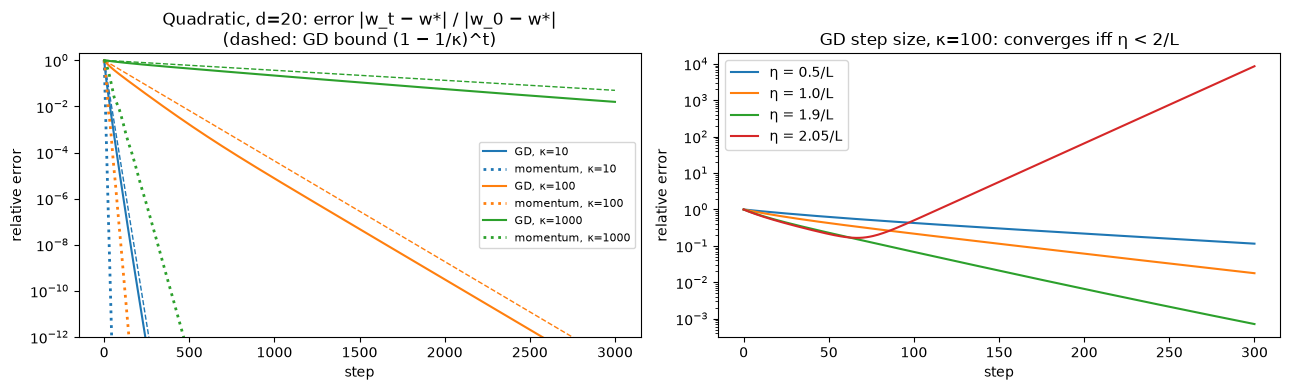

In [6]:
def run_gd(A, b, steps, eta, rho=0.0):
    w, v = torch.zeros(len(b), dtype=torch.float64), torch.zeros(len(b), dtype=torch.float64)
    w_star = torch.linalg.solve(A, b)
    errs = [(w - w_star).norm().item()]
    for _ in range(steps):
        v = rho * v + (A @ w - b)             # gradient of the quadratic
        w = w - eta * v
        errs.append((w - w_star).norm().item())
    return np.array(errs) / errs[0]

steps = 3000
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for kappa, c in zip([10, 100, 1000], ["C0", "C1", "C2"]):
    A, b = make_quadratic(kappa)
    ev = torch.linalg.eigvalsh(A); Lmax, mu = ev.max().item(), ev.min().item()
    gd = run_gd(A, b, steps, eta=1 / Lmax)
    sk = math.sqrt(Lmax / mu)
    hb = run_gd(A, b, steps, eta=4 / (math.sqrt(Lmax) + math.sqrt(mu)) ** 2, rho=((sk - 1) / (sk + 1)) ** 2)
    t = np.arange(steps + 1)
    axes[0].semilogy(t, gd, c, label=f"GD, κ={kappa}")
    axes[0].semilogy(t, (1 - 1 / kappa) ** t, c + "--", lw=1)
    axes[0].semilogy(t, hb, c + ":", lw=2, label=f"momentum, κ={kappa}")
    hit = lambda e: int(np.argmax(e < 1e-6)) if (e < 1e-6).any() else f"> {steps}"
    print(f"κ={kappa:5d}: steps to 1e-6 error: GD {hit(gd)}, momentum {hit(hb)}, Newton 1")
axes[0].set(title="Quadratic, d=20: error |w_t − w*| / |w_0 − w*|\n(dashed: GD bound (1 − 1/κ)^t)", xlabel="step", ylabel="relative error", ylim=(1e-12, 2))
axes[0].legend(fontsize=8)

A, b = make_quadratic(100)
Lmax = torch.linalg.eigvalsh(A).max().item()
for f in [0.5, 1.0, 1.9, 2.05]:
    axes[1].semilogy(run_gd(A, b, 300, eta=f / Lmax), label=f"η = {f}/L")
axes[1].set(title="GD step size, κ=100: converges iff η < 2/L", xlabel="step", ylabel="relative error")
axes[1].legend()
plt.tight_layout(); plt.show()

The measured GD curves follow the dashed $(1-1/\kappa)^t$ bound: each 10× in $\kappa$ costs 10× more steps. Momentum pays only $\sqrt\kappa$. Newton pays one step for any $\kappa$, but on a network with $N$ parameters the Hessian has $N^2$ entries. On the right, $\eta = 1.9/L$ is the fastest of the four (along the steepest direction the error flips sign every step but still shrinks), while $\eta = 2.05/L$ first decreases along the flat directions and then blows up along the steepest one.

**Past exam question (Moed B, 2026)**

True or false: when running vanilla gradient descent on the whole dataset (no mini-batches), the loss decreases at every update step.

**False.** Full-batch GD removes the gradient noise, not the step-size problem. A decrease is guaranteed only for a small enough step: for an $L$-smooth loss, $\eta < 2/L$ (descent lemma). With a larger step the iterate overshoots along the steep directions and the loss goes up, as in the $\eta = 2.05/L$ curve above. The check counts the steps at which the loss increases on the $\kappa=100$ quadratic.

In [7]:
A, b = make_quadratic(100)
Lmax = torch.linalg.eigvalsh(A).max().item()
quad = lambda w: 0.5 * w @ A @ w - b @ w
for f in [1.0, 1.9, 2.05]:
    w = torch.zeros(20, dtype=torch.float64)
    losses = [quad(w).item()]
    for _ in range(300):
        w = w - f / Lmax * (A @ w - b)
        losses.append(quad(w).item())
    ups = int((np.diff(losses) > 0).sum())
    print(f"η = {f}/L: loss went up at {ups:3d} of 300 steps; first increase at step {int(np.argmax(np.diff(losses) > 0)) + 1 if ups else '-'};  final loss {losses[-1]:.3g}")

η = 1.0/L: loss went up at   0 of 300 steps; first increase at step -;  final loss -1.68
η = 1.9/L: loss went up at   0 of 300 steps; first increase at step -;  final loss -1.68
η = 2.05/L: loss went up at 261 of 300 steps; first increase at step 40;  final loss 5.54e+09


### 3.2 Muon: orthogonalize the update with Newton–Schulz

For a weight matrix $W\in\mathbb{R}^{m\times n}$, Muon takes the momentum $M$ (SVD $M=U\Sigma V^\top$) and steps along $UV^\top$: the same magnitude in every singular direction, so the rare directions that the gradient barely visits are not drowned by the dominant ones. An SVD per step is too slow on a GPU; instead apply an odd polynomial $p(X) = aX + b(XX^\top)X + c(XX^\top)^2X$, which acts on each singular value separately, $\sigma \mapsto a\sigma + b\sigma^3 + c\sigma^5$. Normalizing $X = M/\|M\|_F$ first puts every $\sigma$ in $[0,1]$.
- Classic cubic Newton–Schulz $(a,b,c) = (1.5,-0.5,0)$ converges to $\sigma=1$, but small $\sigma$ grow only by 1.5× per step.
- Muon's quintic $(3.4445,-4.7750,2.0315)$ has slope 3.4 at 0, so 5 steps suffice, at the price of landing in roughly $[0.7, 1.2]$ instead of exactly 1.

In [8]:
MUON_COEFFS = (3.4445, -4.7750, 2.0315)

def newton_schulz(M, steps=5, coeffs=MUON_COEFFS, eps=1e-7):
    a, b, c = coeffs
    X = M / (M.norm() + eps)                 # Frobenius norm ≥ spectral norm → all σ ≤ 1
    tall = M.shape[0] > M.shape[1]
    if tall:
        X = X.T                              # work with the smaller Gram matrix X Xᵀ
    for _ in range(steps):
        A = X @ X.T
        X = a * X + (b * A + c * A @ A) @ X
    return X.T if tall else X

In [9]:
torch.manual_seed(0)
# a gradient-like matrix: 8 strong directions on top of noise (σ spread over ~2 orders of magnitude)
M = torch.randn(256, 8) @ torch.randn(8, 128) + 0.3 * torch.randn(256, 128)
U, S, Vh = torch.linalg.svd(M, full_matrices=False)
polar = U @ Vh                               # the exact answer U Vᵀ

for name, kw in [("quintic, 5 steps", {}), ("cubic,   5 steps", dict(coeffs=(1.5, -0.5, 0.0))),
                 ("cubic,  60 steps", dict(steps=60, coeffs=(1.5, -0.5, 0.0)))]:
    O = newton_schulz(M, **kw)
    s = torch.linalg.svdvals(O)
    print(f"{name}: singular values in [{s.min():.3f}, {s.max():.3f}],  max |O − UVᵀ| = {(O - polar).abs().max():.1e}")
print(f"input M: singular values in [{S.min():.2f}, {S.max():.1f}]")

if hasattr(torch.optim, "Muon"):                   # torch ≥ 2.9 ships Muon; its NS runs in bfloat16
    from torch.optim._muon import _zeropower_via_newtonschulz
    ref = _zeropower_via_newtonschulz(M, MUON_COEFFS, 5, 1e-7).float()
    O = newton_schulz(M)
    print(f"vs torch.optim.Muon's NS (bfloat16): relative error |mine − torch|_F / |torch|_F = {(O - ref).norm() / ref.norm():.1e}")

quintic, 5 steps: singular values in [0.682, 1.202],  max |O − UVᵀ| = 4.7e-02
cubic,   5 steps: singular values in [0.024, 1.000],  max |O − UVᵀ| = 2.3e-01
cubic,  60 steps: singular values in [1.000, 1.000],  max |O − UVᵀ| = 5.5e-06
input M: singular values in [1.59, 237.6]
vs torch.optim.Muon's NS (bfloat16): relative error |mine − torch|_F / |torch|_F = 3.0e-02


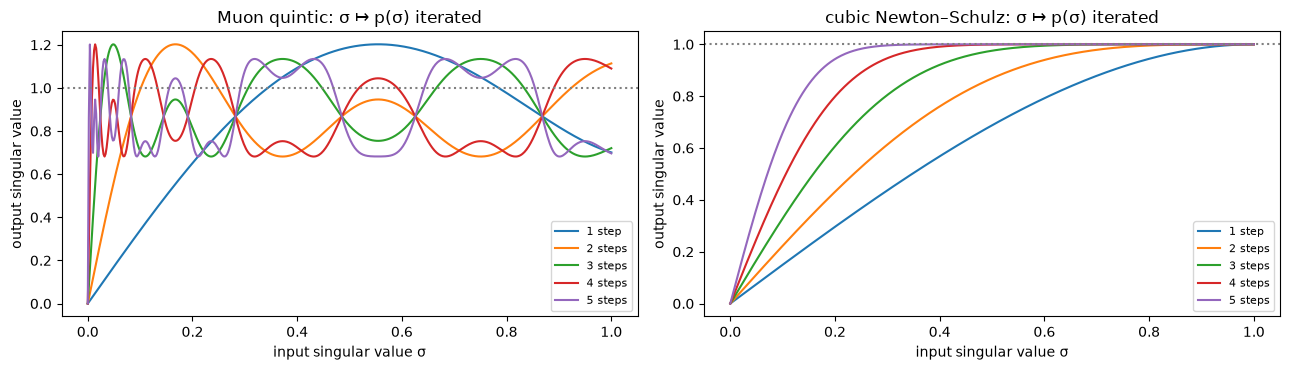

In [10]:
sig = torch.linspace(0, 1, 501)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for coeffs, name, ax in [(MUON_COEFFS, "Muon quintic", axes[0]), ((1.5, -0.5, 0.0), "cubic Newton–Schulz", axes[1])]:
    a, b, c = coeffs
    x = sig.clone()
    for k in range(1, 6):
        x = a * x + b * x ** 3 + c * x ** 5
        ax.plot(sig, x, label=f"{k} step{'s' if k > 1 else ''}")
    ax.axhline(1, color="gray", ls=":")
    ax.set(title=f"{name}: σ ↦ p(σ) iterated", xlabel="input singular value σ", ylabel="output singular value")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The input singular values span 1.6 to 238. After 5 quintic steps they all lie in $[0.68, 1.20]$; 5 cubic steps leave the weakest direction at 0.02, and the cubic iteration needs ~60 steps to reach $UV^\top$ (to $5\cdot10^{-6}$). Muon accepts the $[0.7,1.2]$ band: what matters is that no direction is 100× smaller than another. From the left plot, 5 quintic steps put every $\sigma \ge 1.5\cdot10^{-3}\,\|M\|_F$ into the band; directions weaker than that stay smaller. PyTorch's Newton–Schulz runs in bfloat16 (8 mantissa bits), hence the 3% relative difference.

The Muon optimizer itself is short: Nesterov momentum ($\rho = 0.95$, as an EMA), Newton–Schulz, and a step scaled by $\sqrt{\max(1, m/n)}$. It is used only for the 2-D hidden weight matrices; embeddings, biases and the output layer stay on AdamW.

In [11]:
class MyMuon(torch.optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95, nesterov=True, weight_decay=0.0):
        super().__init__(params, dict(lr=lr, momentum=momentum, nesterov=nesterov, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr, rho = group["lr"], group["momentum"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if "buf" not in state:
                    state["buf"] = torch.zeros_like(p)
                buf = state["buf"].lerp_(p.grad, 1 - rho)          # buf = ρ buf + (1 − ρ) g
                update = p.grad.lerp(buf, rho) if group["nesterov"] else buf
                O = newton_schulz(update)
                p.mul_(1 - lr * group["weight_decay"])
                p.add_(O, alpha=-lr * math.sqrt(max(1, p.shape[0] / p.shape[1])))

if hasattr(torch.optim, "Muon"):
    torch.manual_seed(0)
    W0 = torch.randn(64, 32)
    Wa, Wb = W0.clone().requires_grad_(), W0.clone().requires_grad_()
    oa, ob = MyMuon([Wa], lr=0.02), torch.optim.Muon([Wb], lr=0.02, weight_decay=0.0)
    for _ in range(20):
        G = torch.randn(64, 32)
        Wa.grad, Wb.grad = G + Wa.detach(), G + Wb.detach()
        oa.step(); ob.step()
    print(f"MyMuon vs torch.optim.Muon after 20 steps: max |diff| = {(Wa - Wb).abs().max():.1e}, "
          f"params moved up to {(Wa - W0).abs().max():.2f}")

MyMuon vs torch.optim.Muon after 20 steps: max |diff| = 1.0e-03, params moved up to 0.20


The parameters moved by up to 0.2 and the two implementations differ by $10^{-3}$ (0.5%): the same bfloat16 round-off as above.

## 4. Learning-rate schedules

Both take the step $t\in\{0,\dots,T-1\}$ and return the learning rate. Warmup is linear, $\eta_{\max}\,(t+1)/T_w$ for $t<T_w$.
- **Warmup-cosine**: then $\eta_{\min} + \tfrac12(\eta_{\max}-\eta_{\min})\big(1+\cos(\pi s)\big)$ with $s = (t-T_w)/(T-T_w)$.
- **WSD**: then constant $\eta_{\max}$ until the last fraction $f$ of training (typically 10–20%), then linear decay to $\eta_{\min}$.

In PyTorch, wrap either one with `LambdaLR(opt, lambda t: sched(t, ..., lr_max=1.0))`: `LambdaLR` multiplies the base `lr` by the returned factor.

In [12]:
def warmup_cosine(t, total, warmup, lr_max, lr_min=0.0):
    if t < warmup:
        return lr_max * (t + 1) / warmup
    s = (t - warmup) / (total - warmup)
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * s))

def wsd(t, total, warmup, lr_max, decay_frac=0.2, lr_min=0.0):
    decay_start = total - int(decay_frac * total)
    if t < warmup:
        return lr_max * (t + 1) / warmup
    if t < decay_start:
        return lr_max
    return lr_max + (lr_min - lr_max) * (t - decay_start) / (total - decay_start)

warmup-cosine: max |mine − torch SequentialLR| = 9.7e-17
WSD:           max |mine − torch SequentialLR| = 9.7e-17


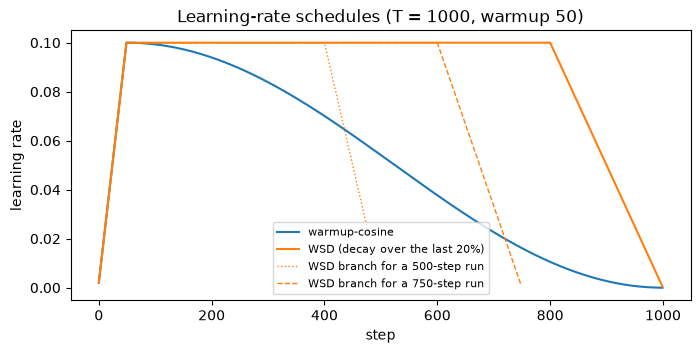

In [13]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch.optim.lr_scheduler")
sch = torch.optim.lr_scheduler
T, W, D, lr_max = 1000, 50, 200, 0.1

def torch_lrs(make):
    opt = torch.optim.SGD([torch.zeros(1, requires_grad=True)], lr=lr_max)
    s, out = make(opt), []
    for _ in range(T):
        out.append(opt.param_groups[0]["lr"]); opt.step(); s.step()
    return np.array(out)

ref_cos = torch_lrs(lambda o: sch.SequentialLR(o, [sch.LinearLR(o, 1 / W, 1.0, W - 1),
                                                   sch.CosineAnnealingLR(o, T - W, 0.0)], [W]))
ref_wsd = torch_lrs(lambda o: sch.SequentialLR(o, [sch.LinearLR(o, 1 / W, 1.0, W - 1), sch.ConstantLR(o, 1.0, 0),
                                                   sch.LinearLR(o, 1.0, 0.0, D)], [W, T - D]))
mine_cos = np.array([warmup_cosine(t, T, W, lr_max) for t in range(T)])
mine_wsd = np.array([wsd(t, T, W, lr_max, decay_frac=D / T) for t in range(T)])
print(f"warmup-cosine: max |mine − torch SequentialLR| = {np.abs(mine_cos - ref_cos).max():.1e}")
print(f"WSD:           max |mine − torch SequentialLR| = {np.abs(mine_wsd - ref_wsd).max():.1e}")

plt.figure(figsize=(8, 3.5))
plt.plot(mine_cos, label="warmup-cosine")
plt.plot(mine_wsd, label="WSD (decay over the last 20%)")
for frac, ls in [(0.5, ":"), (0.75, "--")]:      # WSD branches: decay early from the same stable run
    T2 = int(frac * T)
    plt.plot(range(T2), [wsd(t, T2, W, lr_max, decay_frac=D / T) for t in range(T2)], "C1", ls=ls, lw=1,
             label=f"WSD branch for a {T2}-step run")
plt.title("Learning-rate schedules (T = 1000, warmup 50)")
plt.xlabel("step"); plt.ylabel("learning rate"); plt.legend(fontsize=8); plt.show()

The branches show WSD's practical advantage: the 500-, 750- and 1000-step runs share the same stable phase, so one run plus a short decay per checkpoint gives all three models. A cosine schedule depends on $T$ from step 0, so each length needs its own run.

## 5. Comparing the optimizers

### 5.1 Rosenbrock
$f(x,y) = (1-x)^2 + 100\,(y-x^2)^2$: a curved, narrow valley with the minimum at $(1,1)$, $f=0$. At the start $(-1.5, 2)$ the Hessian has condition number in the hundreds. 1000 steps for each optimizer; learning rates were picked by a coarse sweep ($\times 0.3, \times 1, \times 3$) per method.

SGD       f = 2.76e+00   end = (-0.660, +0.444)


Momentum  f = 5.69e-05   end = (+0.992, +0.985)
Nesterov  f = 2.32e-05   end = (+0.995, +0.990)


AdaGrad   f = 9.61e-01   end = (+0.020, +0.000)
Adam      f = 6.59e-07   end = (+0.999, +0.998)


AdamW     f = 1.15e-01   end = (+0.661, +0.436)


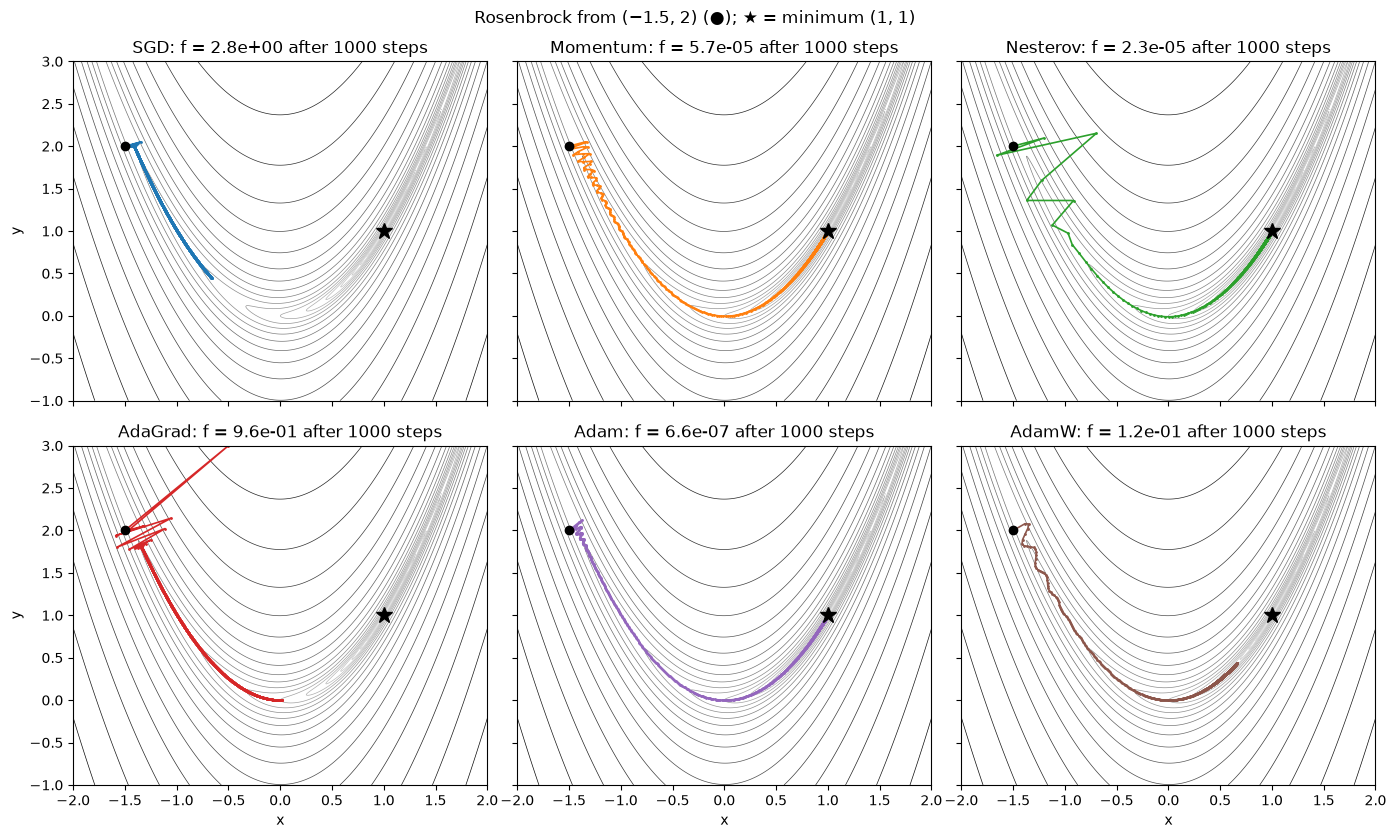

In [14]:
def rosenbrock(w):
    x, y = w[0], w[1]
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

ros_cfg = {
    "SGD":      (MySGD, dict(lr=1e-3)),
    "Momentum": (MySGD, dict(lr=1e-3, momentum=0.9)),
    "Nesterov": (MySGD, dict(lr=1e-3, momentum=0.9, nesterov=True)),
    "AdaGrad":  (MyAdaGrad, dict(lr=1.0)),
    "Adam":     (MyAdam, dict(lr=0.1)),
    "AdamW":    (MyAdamW, dict(lr=0.1, weight_decay=0.1)),
}
paths, final = {}, {}
for name, (cls, kw) in ros_cfg.items():
    w = torch.tensor([-1.5, 2.0], dtype=torch.float64, requires_grad=True)
    opt = cls([w], **kw)
    path = [w.detach().clone()]
    for _ in range(1000):
        opt.zero_grad()
        rosenbrock(w).backward()
        opt.step()
        path.append(w.detach().clone())
    paths[name] = torch.stack(path).numpy()
    final[name] = rosenbrock(w).item()
    print(f"{name:9s} f = {rosenbrock(w).item():.2e}   end = ({w[0].item():+.3f}, {w[1].item():+.3f})")

xs, ys = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-1, 3, 400))
levels = np.log10(rosenbrock(torch.tensor(np.stack([xs, ys]))).numpy() + 1e-3)
fig, axes = plt.subplots(2, 3, figsize=(14, 8.5), sharex=True, sharey=True)
for ax, (name, p), c in zip(axes.flat, paths.items(), [f"C{i}" for i in range(6)]):
    ax.contour(xs, ys, levels, levels=25, cmap="Greys", linewidths=0.5)
    ax.plot(p[:, 0], p[:, 1], color=c, lw=1.2, marker=".", ms=2)
    ax.plot(1, 1, "k*", ms=12); ax.plot(-1.5, 2, "ko")
    ax.set(title=f"{name}: f = {final[name]:.1e} after 1000 steps", xlim=(-2, 2), ylim=(-1, 3))
for ax in axes[1]: ax.set_xlabel("x")
for ax in axes[:, 0]: ax.set_ylabel("y")
fig.suptitle("Rosenbrock from (−1.5, 2) (●); ★ = minimum (1, 1)")
plt.tight_layout(); plt.show()

- **SGD** crawls along the valley floor (the flat direction, condition number in the hundreds) and is still far from $(1,1)$ after 1000 steps. Its learning rate cannot go up: 3× larger diverges on the steep walls.
- **Momentum / Nesterov** use the same learning rate and reach the minimum: the velocity accumulates along the valley.
- **AdaGrad** normalizes each coordinate, so its first steps are $\approx\eta = 1$ per coordinate: it overshoots far up the wall, and by the time it is back in the valley the squared-gradient sum is so large that it stalls halfway, near $(0, 0)$.
- **Adam** reaches $(1,1)$.
- **AdamW** with $\lambda=0.1$ stops short of $(1,1)$: decoupled decay pulls $w$ toward 0 with a force that is not divided by $\sqrt{\hat v}$, and on this 2-D problem that bias is comparable to the gradient near the minimum. On networks, decay is a regularizer and $\lambda$ is chosen for generalization, not to find the training minimum.

✏️ Muon is missing from this plot: what does `newton_schulz` return for a $1\times 2$ "matrix"? (Muon on a vector is sign-like / normalized gradient descent.)

### 5.2 An MLP on FashionMNIST

10k training images, the full 10k test set, an MLP 784–256–256–256–10 (ReLU), batch 128, 4 epochs (312 steps), and the same warmup-cosine schedule (warmup 30 steps) for every optimizer. Muon updates the two hidden weight matrices; AdamW handles the input layer, the output layer and the biases. Learning rates are the usual defaults for each method; nothing was tuned per method beyond that, so read the ranking loosely.

On a Colab GPU you can use the full 60k training set and more epochs (`N_TRAIN = 60_000`, `EPOCHS = 10`).

In [15]:
from torchvision import datasets
N_TRAIN, EPOCHS, BS = 10_000, 4, 128
train_ds = datasets.FashionMNIST("./data", train=True, download=True)
test_ds = datasets.FashionMNIST("./data", train=False, download=True)
g = torch.Generator().manual_seed(0)
idx = torch.randperm(len(train_ds), generator=g)[:N_TRAIN]
norm = lambda x: ((x.float() / 255 - 0.286) / 0.353).view(len(x), -1)
Xtr, ytr = norm(train_ds.data[idx]).to(device), train_ds.targets[idx].to(device)
Xte, yte = norm(test_ds.data).to(device), test_ds.targets.to(device)
print(Xtr.shape, Xte.shape)

def make_mlp():
    return nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(),
                         nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 10)).to(device)

def make_opts(name, net):
    ps = list(net.parameters())
    if name == "SGD":       return [MySGD(ps, lr=0.1)]
    if name == "Momentum":  return [MySGD(ps, lr=0.05, momentum=0.9)]
    if name == "Nesterov":  return [MySGD(ps, lr=0.05, momentum=0.9, nesterov=True)]
    if name == "AdaGrad":   return [MyAdaGrad(ps, lr=0.05)]
    if name == "Adam":      return [MyAdam(ps, lr=1e-3)]
    if name == "AdamW":     return [MyAdamW(ps, lr=1e-3, weight_decay=0.05)]
    if name == "Muon":
        hidden = [net[2].weight, net[4].weight]
        rest = [p for p in ps if all(p is not h for h in hidden)]
        return [MyMuon(hidden, lr=0.02), MyAdamW(rest, lr=1e-3, weight_decay=0.05)]

def train(name, seed=0):
    torch.manual_seed(seed)
    net = make_mlp()
    opts = make_opts(name, net)
    total = EPOCHS * (N_TRAIN // BS)
    scheds = [torch.optim.lr_scheduler.LambdaLR(o, lambda t: warmup_cosine(t, total, 30, 1.0)) for o in opts]
    losses, gen = [], torch.Generator().manual_seed(seed)
    for _ in range(EPOCHS):
        perm = torch.randperm(N_TRAIN, generator=gen)
        for i in range(N_TRAIN // BS):
            bi = perm[i * BS:(i + 1) * BS].to(device)
            loss = F.cross_entropy(net(Xtr[bi]), ytr[bi])
            for o in opts: o.zero_grad()
            loss.backward()
            for o in opts: o.step()
            for s in scheds: s.step()
            losses.append(loss.item())
    with torch.no_grad():
        acc = (net(Xte).argmax(1) == yte).float().mean().item()
    return np.array(losses), acc

results = {}
t0 = time.time()
for name in ["SGD", "Momentum", "Nesterov", "AdaGrad", "Adam", "AdamW", "Muon"]:
    results[name] = train(name)
    print(f"{name:9s} final train loss (last 30 steps) {results[name][0][-30:].mean():.3f}   test acc {results[name][1]:.3f}")
print(f"{time.time() - t0:.0f}s")

torch.Size([10000, 784]) torch.Size([10000, 784])


SGD       final train loss (last 30 steps) 0.532   test acc 0.800


Momentum  final train loss (last 30 steps) 0.387   test acc 0.842


Nesterov  final train loss (last 30 steps) 0.360   test acc 0.848


AdaGrad   final train loss (last 30 steps) 0.394   test acc 0.840


Adam      final train loss (last 30 steps) 0.392   test acc 0.838


AdamW     final train loss (last 30 steps) 0.392   test acc 0.840


Muon      final train loss (last 30 steps) 0.291   test acc 0.857
29s


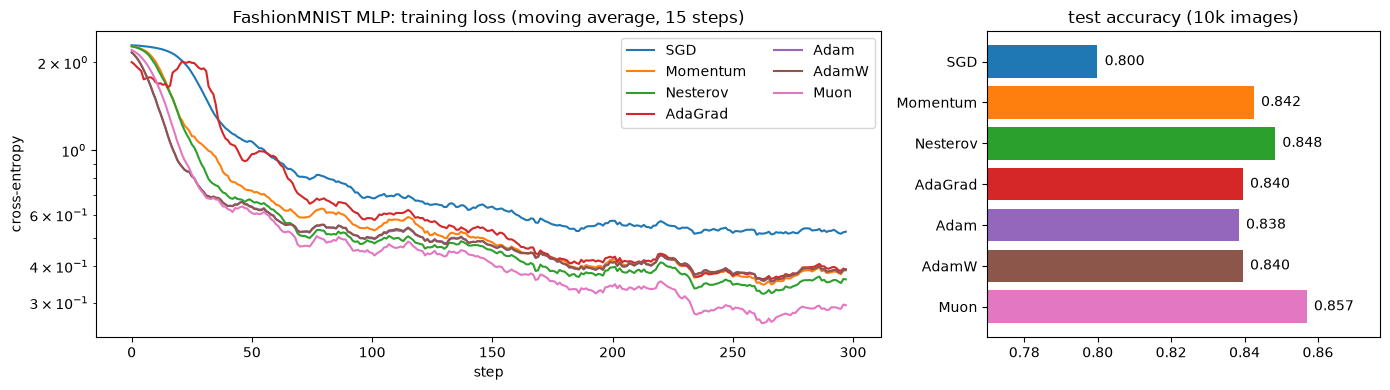

In [16]:
smooth = lambda x, k=15: np.convolve(x, np.ones(k) / k, mode="valid")
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw=dict(width_ratios=[2, 1]))
for name, (losses, acc) in results.items():
    axes[0].plot(smooth(losses), label=name)
axes[0].set(title="FashionMNIST MLP: training loss (moving average, 15 steps)", xlabel="step", ylabel="cross-entropy", yscale="log")
axes[0].legend(ncol=2)
names = list(results)
accs = [results[n][1] for n in names]
axes[1].barh(names, accs, color=[f"C{i}" for i in range(len(names))])
for i, a in enumerate(accs):
    axes[1].text(a + 0.002, i, f"{a:.3f}", va="center")
axes[1].set(title="test accuracy (10k images)", xlim=(min(accs) - 0.03, max(accs) + 0.02))
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

- **Muon** reaches the lowest training loss (≈0.29) and the best test accuracy (≈0.86). Its non-hidden parameters use the same AdamW as the AdamW run (≈0.39, ≈0.84), so orthogonalizing the two hidden-layer updates is the only difference.
- **Momentum / Nesterov** (0.842 / 0.848) match or beat Adam, AdamW and AdaGrad (≈0.84). **Plain SGD** at lr 0.1 starts slowest and ends last (0.800).
- **Adam vs AdamW** are almost identical here: with $\lambda = 0.05$ and $\sum_t \eta_t \approx 0.16$, decoupled decay shrinks the weights by less than 1%.
- One seed and 312 steps: do not read differences below ~0.01 as a ranking.

✏️ Replace `warmup_cosine` by `wsd` in `train` and re-run Adam and Muon. Where do the two loss curves differ, and is the final test accuracy different?

## 6. Why Adam needs warmup

Almost every large training run uses Adam(W) with a linear warmup. The reason is in the first few steps of the second-moment estimate.

**Step 1.** $m_1 = (1-\beta_1)g_1$, $v_1 = (1-\beta_2)g_1^2$.
- Without bias correction, the update is $\eta\,\frac{(1-\beta_1)}{\sqrt{1-\beta_2}}\operatorname{sign}(g_1) = \eta\cdot\frac{0.1}{0.0316}\operatorname{sign}(g_1) \approx 3.16\,\eta$ per coordinate: 3× too large, in every coordinate.
- With bias correction, $\hat m_1/\sqrt{\hat v_1} = \operatorname{sign}(g_1)$: every coordinate moves by exactly $\eta$, whether its gradient is signal or noise, large or $10^{-6}$.

**Later.** $\hat v_t$ averages $\approx\min(t, 1/(1-\beta_2)) = \min(t, 1000)$ squared gradients. For small $t$ it is estimated from a handful of samples, so the per-coordinate step $\eta/\sqrt{\hat v_t}$ has a very large variance (Liu et al., 2020, "On the variance of the adaptive learning rate and beyond", which led to RAdam). In steady state on noise-dominated coordinates $\hat m_t$ averages the noise out, $|\hat m_t|/\sqrt{\hat v_t} \approx \sqrt{(1-\beta_1)/(1+\beta_1)} \approx 0.23$, so the first steps are several times larger than the steps Adam takes later at the same $\eta$.

**Experiment 1.** Pure-noise gradients $g_t \sim \mathcal N(0, 1)$ on a 100k-dimensional parameter (a stationary point seen through minibatch noise). We record the RMS of the update divided by the peak $\eta$ for the first 200 steps, and the spread of the per-coordinate step $1/\sqrt{\hat v_t}$.

step   1: update RMS / lr   no bias corr. 3.16 | bias corr. 1.00 | bias corr. + warmup 0.010   | 1/sqrt(v̂): median 1.47, 99th pct 90.3
step   2: update RMS / lr   no bias corr. 3.01 | bias corr. 0.71 | bias corr. + warmup 0.014   | 1/sqrt(v̂): median 1.20, 99th pct 10.4
step   5: update RMS / lr   no bias corr. 2.61 | bias corr. 0.45 | bias corr. + warmup 0.023   | 1/sqrt(v̂): median 1.07, 99th pct 3.0
step  10: update RMS / lr   no bias corr. 2.16 | bias corr. 0.33 | bias corr. + warmup 0.033   | 1/sqrt(v̂): median 1.03, 99th pct 2.0
step  50: update RMS / lr   no bias corr. 1.04 | bias corr. 0.23 | bias corr. + warmup 0.115   | 1/sqrt(v̂): median 1.01, 99th pct 1.3
step 100: update RMS / lr   no bias corr. 0.74 | bias corr. 0.23 | bias corr. + warmup 0.230   | 1/sqrt(v̂): median 1.00, 99th pct 1.2
step 200: update RMS / lr   no bias corr. 0.54 | bias corr. 0.23 | bias corr. + warmup 0.230   | 1/sqrt(v̂): median 1.00, 99th pct 1.1


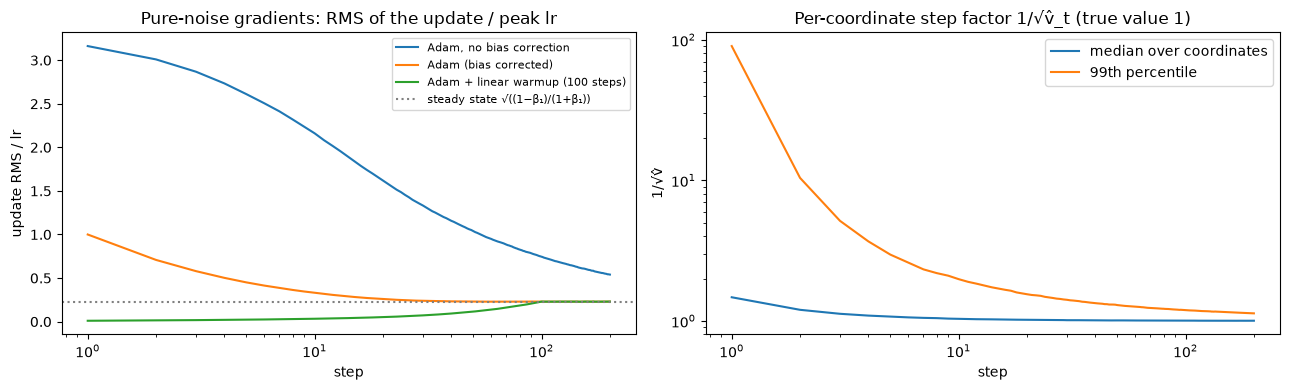

In [17]:
def adam_update_rms(steps=200, d=100_000, warmup=0, **kw):
    torch.manual_seed(0)
    w = torch.zeros(d, requires_grad=True)
    lr = 1e-3
    opt = MyAdam([w], lr=lr, **kw)
    rms, inv_sqrt_v = [], []
    for t in range(steps):
        opt.param_groups[0]["lr"] = lr * min(1.0, (t + 1) / warmup) if warmup else lr
        w.grad = torch.randn(d)
        before = w.detach().clone()
        opt.step()
        rms.append(((w.detach() - before).pow(2).mean().sqrt() / lr).item())
        st = opt.state[w]
        v_hat = st["v"] / (1 - 0.999 ** st["t"])
        inv_sqrt_v.append(torch.quantile(1 / v_hat[:20_000].sqrt(), torch.tensor([0.5, 0.99])).numpy())
    return np.array(rms), np.array(inv_sqrt_v)

rms_nobc, _ = adam_update_rms(bias_correction=False)
rms_bc, spread = adam_update_rms()
rms_warm, _ = adam_update_rms(warmup=100)
for t in [1, 2, 5, 10, 50, 100, 200]:
    print(f"step {t:3d}: update RMS / lr   no bias corr. {rms_nobc[t-1]:.2f} | bias corr. {rms_bc[t-1]:.2f} | "
          f"bias corr. + warmup {rms_warm[t-1]:.3f}   | 1/sqrt(v̂): median {spread[t-1, 0]:.2f}, 99th pct {spread[t-1, 1]:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
steps = np.arange(1, 201)
axes[0].plot(steps, rms_nobc, label="Adam, no bias correction")
axes[0].plot(steps, rms_bc, label="Adam (bias corrected)")
axes[0].plot(steps, rms_warm, label="Adam + linear warmup (100 steps)")
axes[0].axhline(math.sqrt(0.1 / 1.9), color="gray", ls=":", label="steady state √((1−β₁)/(1+β₁))")
axes[0].set(title="Pure-noise gradients: RMS of the update / peak lr", xlabel="step", ylabel="update RMS / lr", xscale="log")
axes[0].legend(fontsize=8)
axes[1].plot(steps, spread[:, 0], label="median over coordinates")
axes[1].plot(steps, spread[:, 1], label="99th percentile")
axes[1].set(title="Per-coordinate step factor 1/√v̂_t (true value 1)", xlabel="step", ylabel="1/√v̂", xscale="log", yscale="log")
axes[1].legend()
plt.tight_layout(); plt.show()

- **No bias correction**: the first update is $3.16\,\eta$ per coordinate, as computed above, and it stays above $\eta$ for ~50 steps: $v_t$ underestimates $\mathbb E[g^2]$ by the factor $1-\beta_2^t$, which is still 0.05 at step 50.
- **Bias corrected**: step 1 is exactly $\eta$ per coordinate (sign descent), and the RMS decays to the steady state $0.23\,\eta$ within ~30 steps. Steps 1–10 are 1.4–4.3× larger than the steps Adam takes later, in every coordinate, including those whose gradient is pure noise.
- **Right panel**: the median of $1/\sqrt{\hat v_t}$ is close to 1 from the start, but at step 1 one coordinate in a hundred has $1/\sqrt{\hat v_1} > 90$ (its first gradient happened to be near 0). The 99th percentile is 2.0 at step 10 and 1.2 at step 100. The adaptive step size is least reliable exactly when the updates are largest.
- **Warmup** multiplies the update by $t/T_w$, so the large early steps never happen; from step 100 on it coincides with the bias-corrected curve.

**Experiment 2: does it matter for training?** A deeper MLP (6 layers, width 256) on the same FashionMNIST subset, Adam at a large learning rate $\eta = 10^{-2}$, 400 steps, 3 seeds. Four variants: with or without bias correction, with or without a 100-step linear warmup.

In [18]:
def make_deep_mlp(depth=6, width=256):
    layers = [nn.Linear(784, width), nn.ReLU()]
    for _ in range(depth - 2):
        layers += [nn.Linear(width, width), nn.ReLU()]
    return nn.Sequential(*layers, nn.Linear(width, 10)).to(device)

def train_adam(seed, lr=1e-2, warmup=0, bias_correction=True, steps=400):
    torch.manual_seed(seed)
    net = make_deep_mlp()
    opt = MyAdam(net.parameters(), lr=lr, bias_correction=bias_correction)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda t: min(1.0, (t + 1) / warmup) if warmup else 1.0)
    gen, losses = torch.Generator().manual_seed(seed), []
    for _ in range(steps):
        bi = torch.randint(0, N_TRAIN, (BS,), generator=gen).to(device)
        loss = F.cross_entropy(net(Xtr[bi]), ytr[bi])
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        losses.append(loss.item())
    with torch.no_grad():
        acc = (net(Xte).argmax(1) == yte).float().mean().item()
    return np.array(losses), acc

variants = {"no warmup": dict(), "no warmup, no bias correction": dict(bias_correction=False),
            "warmup 100": dict(warmup=100), "warmup 100, no bias correction": dict(warmup=100, bias_correction=False)}
runs = {}
for name, kw in variants.items():
    runs[name] = [train_adam(seed, **kw) for seed in range(3)]
    early = [r[0][:50].max() for r in runs[name]]
    late = [r[0][-50:].mean() for r in runs[name]]
    accs = [r[1] for r in runs[name]]
    print(f"{name:31s} max loss in steps 1–50: {np.round(early, 1)}   loss in last 50 steps: {np.round(late, 3)}   test acc: {np.round(accs, 3)}")

no warmup                       max loss in steps 1–50: [2.9 2.6 2.7]   loss in last 50 steps: [0.465 0.525 0.613]   test acc: [0.813 0.799 0.748]


no warmup, no bias correction   max loss in steps 1–50: [190.2 128.2 173. ]   loss in last 50 steps: [0.753 2.303 1.651]   test acc: [0.698 0.1   0.324]


warmup 100                      max loss in steps 1–50: [2.3 2.3 2.3]   loss in last 50 steps: [0.474 0.543 0.529]   test acc: [0.796 0.806 0.737]


warmup 100, no bias correction  max loss in steps 1–50: [2.3 2.3 2.9]   loss in last 50 steps: [1.035 0.677 2.303]   test acc: [0.557 0.732 0.1  ]


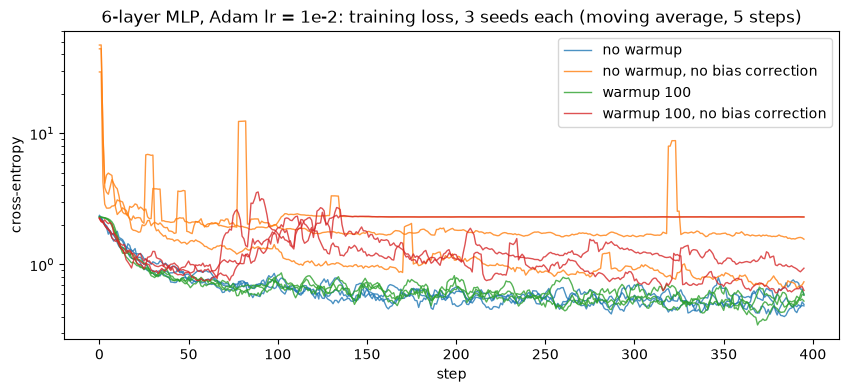

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
for i, (name, rs) in enumerate(runs.items()):
    for j, (losses, _) in enumerate(rs):
        ax.plot(smooth(losses, 5), color=f"C{i}", alpha=0.8, lw=1, label=name if j == 0 else None)
ax.set(title="6-layer MLP, Adam lr = 1e-2: training loss, 3 seeds each (moving average, 5 steps)",
       xlabel="step", ylabel="cross-entropy", yscale="log")
ax.legend(); plt.show()

- **With bias correction**, warmup removes the early loss spike (max loss in steps 1–50: 2.6–2.9 without warmup, 2.3 = the initial loss with warmup). On this small MLP the final loss and test accuracy of the two are within the seed spread (the exact numbers change between CPU, GPU and MPS: at $\eta = 10^{-2}$ these runs are chaotic). Warmup matters more at scale (transformers, large batches, larger $\eta$), where an early oversized step can leave the model in a region it does not recover from.
- **Without bias correction**, the $3.16\,\eta$ first steps push the loss above 100 in all three seeds; the runs stay erratic and end far below the bias-corrected ones, at least one seed at chance (test accuracy 0.10).
- **A 100-step warmup does not rescue it**: no blow-up in the first 50 steps, but the loss spikes once the full $\eta$ is reached, and every seed ends with a higher training loss than every bias-corrected run. Without bias correction $v_t$ is too small by the factor $1-\beta_2^t$, which is only 0.095 at step 100, so when warmup ends the steps are still $\approx 1/\sqrt{0.095}\approx 3\times$ too large. The bias lasts $\sim 1/(1-\beta_2) = 1000$ steps, and warmup has to cover it. BERT's original optimizer had no bias correction and used a 10,000-step warmup.

✏️ Replace the linear warmup by `torch.optim.RAdam` (no warmup): RAdam switches the adaptive term on only once the variance of $\hat v_t$ is small enough, and uses plain momentum SGD before that. Does it match the warmup run?

## 7. If time: L-BFGS

The lecture's quasi-Newton method: L-BFGS approximates $H^{-1}g$ from the last $m$ pairs $(w_{k+1}-w_k,\ g_{k+1}-g_k)$, at $O(mN)$ memory instead of $O(N^2)$, and runs a line search. It works well with full-batch, deterministic gradients (it needs a `closure` that recomputes the loss). Back to Rosenbrock:

In [20]:
w = torch.tensor([-1.5, 2.0], dtype=torch.float64, requires_grad=True)
opt = torch.optim.LBFGS([w], lr=1, max_iter=200, history_size=10, line_search_fn="strong_wolfe")
def closure():
    opt.zero_grad()
    loss = rosenbrock(w)
    loss.backward()
    return loss
opt.step(closure)
st = opt.state[opt.param_groups[0]["params"][0]]
print(f"L-BFGS: f = {rosenbrock(w).item():.1e} at ({w[0].item():.6f}, {w[1].item():.6f}) "
      f"after {st['n_iter']} iterations, {st['func_evals']} function evaluations")

L-BFGS: f = 2.8e-10 at (0.999983, 0.999967) after 40 iterations, 50 function evaluations


L-BFGS reaches $(1,1)$ to 5 digits in 40 iterations (50 loss + gradient evaluations), where Adam needed 1000 steps to reach $f\approx 7\cdot 10^{-7}$. The catch is the line search and the curvature pairs: both assume exact, full-batch gradients. With minibatch noise the pairs $(\Delta w, \Delta g)$ are inconsistent, which is one reason deep learning trains with first-order methods.

## Summary
- An optimizer is a loop over `param_groups` with a per-parameter `state`; SGD, momentum, Nesterov, AdaGrad, Adam and AdamW are each a few lines and match `torch.optim` to float64 round-off.
- GD needs $\sim\kappa$ steps per digit of accuracy, momentum $\sim\sqrt\kappa$, Newton 1, at a cost of $O(N^2)$ memory and $O(N^3)$ time per step.
- Muon steps along the orthogonalized momentum $UV^\top$; 5 quintic Newton–Schulz iterations put all singular values in $\approx[0.7, 1.2]$ with matrix products only.
- Warmup-cosine and WSD are a few lines each; WSD lets one run serve several training lengths.
- Adam's first steps are large: $\eta\cdot\operatorname{sign}(g)$ at step 1, about 4× the steady-state step on noisy coordinates, and $3.16\,\eta$ without bias correction; meanwhile $1/\sqrt{\hat v_t}$ is estimated from a handful of samples. Linear warmup keeps the early steps small; without bias correction the warmup must last $\sim 1/(1-\beta_2)$ steps.

**Further watching:** 3Blue1Brown, [*Gradient descent, how neural networks learn*](https://www.youtube.com/watch?v=IHZwWFHWa-w); Stanford CS231n 2017, [Lecture 6](https://www.youtube.com/watch?v=wEoyxE0GP2M) (training I) and [Lecture 7](https://www.youtube.com/watch?v=_JB0AO7QxSA) (training II: optimizers, schedules); Karpathy, [*makemore part 4: becoming a backprop ninja*](https://www.youtube.com/watch?v=q8SA3rM6ckI).